In [271]:
import pandas as pd

df = pd.read_csv('./employee_data.csv')
print(df.head())

   Age Attrition  ... YearsSinceLastPromotion  YearsWithCurrManager
0   34        No  ...                       1                     3
1   38        No  ...                       1                     0
2   51        No  ...                       0                     0
3   60        No  ...                       2                     2
4   23        No  ...                       1                     4

[5 rows x 35 columns]


In [272]:
print(df.head()['StandardHours'].nunique())
print(df.head()['Over18'].nunique())
print(df.head()['EmployeeCount'].nunique())

df = df.drop(columns=['StandardHours', 'Over18', 'EmployeeCount', 'EmployeeNumber'])

1
1
1


In [273]:
df.isna().sum()

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSinceLastPromotion     0
YearsWithCurrManager        0
dtype: int64

In [274]:
df['NumCompaniesWorked'].describe()

count    1249.000000
mean        2.667734
std         2.475377
min         0.000000
25%         1.000000
50%         2.000000
75%         4.000000
max         9.000000
Name: NumCompaniesWorked, dtype: float64

In [275]:
df['Attrition'] = df['Attrition'].map({'Yes': 1, 'No': 0})
df['income_per_year_experience'] = df['MonthlyIncome'] / (df['TotalWorkingYears'] + 1)
df['years_without_promotion_ratio'] = df['YearsSinceLastPromotion'] / (df['YearsAtCompany'] + 1)
df['OverTime'] = df['OverTime'].map({'Yes': 1, 'No': 0})
df['MaritalStatus'] = df['MaritalStatus'].map({'Single': 0, 'Divorced': 1, 'Married': 2,})
df['BusinessTravel'] = df['BusinessTravel'].map({'Non-Travel': 0, 'Travel_Rarely': 1, 'Travel_Frequently': 2})

df['Total_Satisfaction'] = df['JobSatisfaction'] + df['EnvironmentSatisfaction'] + df['RelationshipSatisfaction'] + df['WorkLifeBalance']
df['Years_Per_Company'] = df['TotalWorkingYears'] / (df['NumCompaniesWorked'] + 1)
df['Burnout_Risk'] = df['OverTime'] * (16 - df['Total_Satisfaction'])
df['Tenure_to_Age_Ratio'] = df['YearsAtCompany'] / df['Age']
df['Commute_Penalty'] = df['DistanceFromHome'] / (df['Total_Satisfaction'] + 1)


df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,income_per_year_experience,years_without_promotion_ratio,Total_Satisfaction,Years_Per_Company,Burnout_Risk,Tenure_to_Age_Ratio,Commute_Penalty
0,34,0,2,702,Research & Development,16,4,Life Sciences,3,Female,100,2,1,Research Scientist,4,0,2553,8306,1,0,16,3,3,0,6,3,3,5,2,1,3,364.714286,0.166667,13,3.000000,0,0.147059,1.142857
1,38,0,1,833,Research & Development,18,3,Medical,2,Male,60,1,2,Healthcare Representative,4,2,5811,24539,3,1,16,3,3,1,15,2,3,1,0,1,0,363.187500,0.500000,12,3.750000,4,0.026316,1.384615
2,51,0,1,833,Research & Development,1,3,Life Sciences,3,Male,96,3,1,Research Scientist,4,2,2723,23231,1,0,11,3,2,0,1,0,2,1,0,0,0,1361.500000,0.000000,11,0.500000,0,0.019608,0.083333
3,60,0,1,1179,Sales,16,4,Marketing,1,Male,84,3,2,Sales Executive,1,0,5405,11924,8,0,14,3,4,0,10,1,3,2,2,2,2,491.363636,0.666667,9,1.111111,0,0.033333,1.600000
4,23,0,1,571,Research & Development,12,2,Other,4,Male,78,3,1,Laboratory Technician,4,0,2647,13672,1,0,13,3,3,0,5,6,4,5,2,1,4,441.166667,0.166667,15,2.500000,0,0.217391,0.750000


In [276]:
churnCount = df['Attrition'].value_counts()
churnCount

Attrition
0    1048
1     201
Name: count, dtype: int64

In [277]:
from sklearn.preprocessing import OneHotEncoder

columns_to_encode = ['Department', 'EducationField', 'Gender', 'JobRole']
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
encoded_data = ohe.fit_transform(df[columns_to_encode])
encoded_df = pd.DataFrame(encoded_data, columns=ohe.get_feature_names_out(columns_to_encode))
df = pd.concat([df.drop(columns=columns_to_encode), encoded_df], axis=1)
print(df.columns)

Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'DistanceFromHome',
       'Education', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement',
       'JobLevel', 'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome',
       'MonthlyRate', 'NumCompaniesWorked', 'OverTime', 'PercentSalaryHike',
       'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager', 'income_per_year_experience',
       'years_without_promotion_ratio', 'Total_Satisfaction',
       'Years_Per_Company', 'Burnout_Risk', 'Tenure_to_Age_Ratio',
       'Commute_Penalty', 'Department_Human Resources',
       'Department_Research & Development', 'Department_Sales',
       'EducationField_Human Resources', 'EducationField_Life Sciences',
       'EducationField_Marketing', 'EducationField_Medical',
       'EducationField_Other

In [278]:
df.corrwith(df['Attrition']).sort_values(ascending=False)

Attrition                            1.000000
Burnout_Risk                         0.275789
OverTime                             0.223517
JobRole_Sales Representative         0.142064
BusinessTravel                       0.128207
JobRole_Laboratory Technician        0.128079
Commute_Penalty                      0.124915
income_per_year_experience           0.124671
DistanceFromHome                     0.085921
Department_Sales                     0.073414
EducationField_Technical Degree      0.050831
EducationField_Marketing             0.050323
EducationField_Human Resources       0.049799
NumCompaniesWorked                   0.046480
JobRole_Human Resources              0.034500
Gender_Male                          0.024300
JobRole_Sales Executive              0.018855
Department_Human Resources           0.015897
MonthlyRate                          0.015846
PerformanceRating                    0.013731
PercentSalaryHike                    0.000026
years_without_promotion_ratio     

In [279]:
from sklearn.preprocessing import StandardScaler

X = df.drop('Attrition', axis=1)
y = df['Attrition']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X = pd.DataFrame(X_scaled, columns=X.columns)

In [280]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [281]:
from sklearn.metrics import classification_report
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

pred = model.predict(X_test)
print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           0       0.88      0.98      0.92       210
           1       0.69      0.28      0.39        40

    accuracy                           0.86       250
   macro avg       0.78      0.63      0.66       250
weighted avg       0.85      0.86      0.84       250



<Axes: >

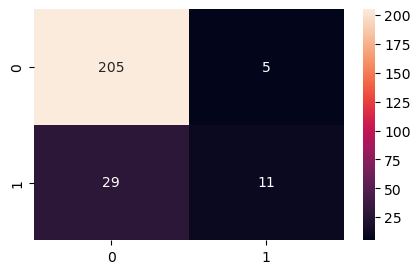

In [282]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, pred)
plt.figure(figsize = (5,3))
sns.heatmap(cm, annot=True, fmt='g')

In [283]:
from xgboost import XGBClassifier

model = XGBClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

pred = model.predict(X_test)
print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           0       0.90      0.94      0.92       210
           1       0.60      0.45      0.51        40

    accuracy                           0.86       250
   macro avg       0.75      0.70      0.72       250
weighted avg       0.85      0.86      0.86       250



<Axes: >

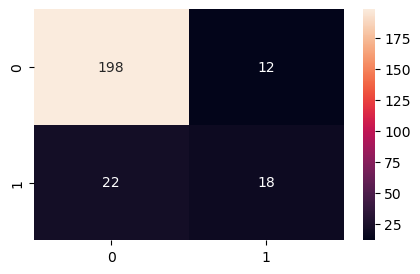

In [284]:
cm = confusion_matrix(y_test, pred)
plt.figure(figsize = (5,3))
sns.heatmap(cm, annot=True, fmt='g')

In [285]:
from xgboost import XGBRFClassifier

model = XGBRFClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

pred = model.predict(X_test)
print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           0       0.89      0.91      0.90       210
           1       0.47      0.42      0.45        40

    accuracy                           0.83       250
   macro avg       0.68      0.67      0.67       250
weighted avg       0.83      0.83      0.83       250



<Axes: >

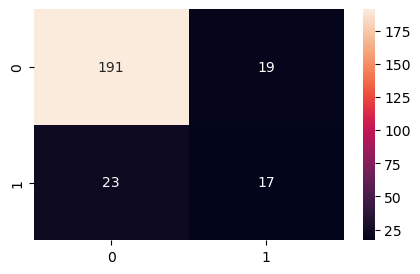

In [286]:
cm = confusion_matrix(y_test, pred)
plt.figure(figsize = (5,3))
sns.heatmap(cm, annot=True, fmt='g')

In [287]:
from sklearn.svm import SVC
from sklearn.model_selection import cross_val_score

clf_svm = SVC()
score = cross_val_score(clf_svm, X_train, y_train, cv=5, scoring = 'accuracy', n_jobs=-1)
score,score.mean()

(array([0.85      , 0.9       , 0.855     , 0.86      , 0.87437186]),
 np.float64(0.8678743718592965))

0.872


<Axes: >

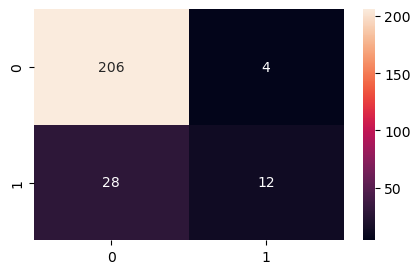

In [288]:
model = clf_svm.fit(X_train, y_train)
print(model.score(X_test, y_test))

pred = model.predict(X_test)
cm_svc = confusion_matrix(y_test, pred)
plt.figure(figsize = (5,3))
sns.heatmap(cm_svc, annot=True, fmt='g')

In [289]:
from imblearn.combine import SMOTETomek
from collections import Counter

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Original dataset shape: {Counter(y_train)}")

sm = SMOTETomek(sampling_strategy=0.6, random_state=42) 
X_train, y_train = sm.fit_resample(X_train, y_train)

print(f"Resampled dataset shape: {Counter(y_train)}")

Original dataset shape: Counter({0: 838, 1: 161})
Resampled dataset shape: Counter({0: 835, 1: 499})


In [290]:
from sklearn.metrics import classification_report
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

pred = model.predict(X_test)
print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           0       0.89      0.97      0.92       210
           1       0.67      0.35      0.46        40

    accuracy                           0.87       250
   macro avg       0.78      0.66      0.69       250
weighted avg       0.85      0.87      0.85       250



<Axes: >

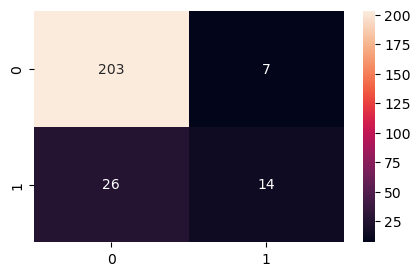

In [291]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, pred)
plt.figure(figsize = (5,3))
sns.heatmap(cm, annot=True, fmt='g')

In [292]:
from xgboost import XGBClassifier

model = XGBClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

pred = model.predict(X_test)
print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           0       0.89      0.95      0.92       210
           1       0.59      0.40      0.48        40

    accuracy                           0.86       250
   macro avg       0.74      0.67      0.70       250
weighted avg       0.84      0.86      0.85       250



<Axes: >

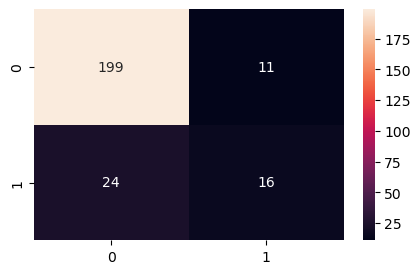

In [293]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, pred)
plt.figure(figsize = (5,3))
sns.heatmap(cm, annot=True, fmt='g')

In [294]:
from xgboost import XGBRFClassifier

model = XGBRFClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

pred = model.predict(X_test)
print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           0       0.90      0.90      0.90       210
           1       0.47      0.45      0.46        40

    accuracy                           0.83       250
   macro avg       0.68      0.68      0.68       250
weighted avg       0.83      0.83      0.83       250



<Axes: >

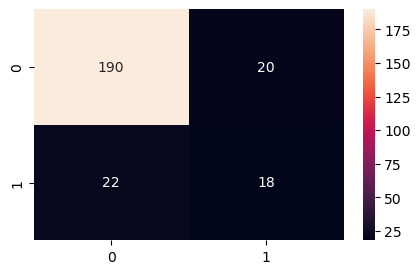

In [295]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, pred)
plt.figure(figsize = (5,3))
sns.heatmap(cm, annot=True, fmt='g')

In [296]:
from sklearn.svm import SVC
from sklearn.model_selection import cross_val_score

clf_svm = SVC()
score = cross_val_score(clf_svm, X_train, y_train, cv=5, scoring = 'accuracy', n_jobs=-1)
score,score.mean()

(array([0.86516854, 0.87640449, 0.93258427, 0.94007491, 0.93609023]),
 np.float64(0.9100644870603475))

<Axes: >

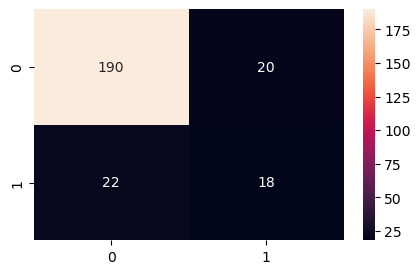

In [297]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, pred)
plt.figure(figsize = (5,3))
sns.heatmap(cm, annot=True, fmt='g')

In [298]:
from sklearn.model_selection import GridSearchCV

model = RandomForestClassifier(random_state=42)

param_grid = {
    'max_depth': [5, 10, None],
    'max_features': ['sqrt', 'log2'],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'min_weight_fraction_leaf': [0.0, 0.1, 0.2],
    'criterion': ['gini', 'entropy']
}

grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    scoring='accuracy',
    cv=3,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)
print("Best parameters found: ", grid_search.best_params_)
best_rf = grid_search.best_estimator_
pred = best_rf.predict(X_test)
print(classification_report(y_test, pred))

Best parameters found:  {'criterion': 'gini', 'max_depth': None, 'max_features': 'log2', 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0}
              precision    recall  f1-score   support

           0       0.89      0.96      0.92       210
           1       0.62      0.38      0.47        40

    accuracy                           0.86       250
   macro avg       0.76      0.67      0.70       250
weighted avg       0.85      0.86      0.85       250



              precision    recall  f1-score   support

           0       0.91      0.91      0.91       210
           1       0.53      0.50      0.51        40

    accuracy                           0.85       250
   macro avg       0.72      0.71      0.71       250
weighted avg       0.84      0.85      0.85       250



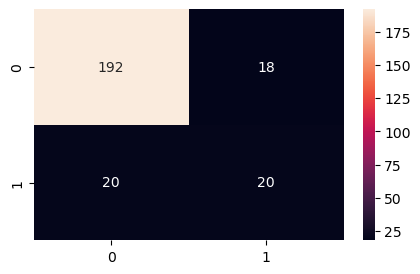

In [299]:
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.metrics import confusion_matrix

ratio = float(y_train.value_counts()[0] / y_train.value_counts()[1])

xgb = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    scale_pos_weight=ratio,
    random_state=42
)

param_grid = {
    'max_depth': [3, 4, 5],
    'learning_rate': [0.01, 0.05, 0.1],
    'n_estimators': [100, 200, 300],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    scoring='f1_macro', 
    cv=cv,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)
best_xgb = grid_search.best_estimator_
y_pred = best_xgb.predict(X_test)

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize = (5,3))
sns.heatmap(cm, annot=True, fmt='g')
print(classification_report(y_test, y_pred))

/opt/anaconda3/lib/python3.13/site-packages/sklearn/preprocessing/_function_transformer.py:390: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  return func(X, **(kw_args if kw_args else {}))


              precision    recall  f1-score   support

           0       0.89      0.94      0.91       210
           1       0.55      0.40      0.46        40

    accuracy                           0.85       250
   macro avg       0.72      0.67      0.69       250
weighted avg       0.84      0.85      0.84       250



/opt/anaconda3/lib/python3.13/site-packages/sklearn/preprocessing/_function_transformer.py:390: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  return func(X, **(kw_args if kw_args else {}))


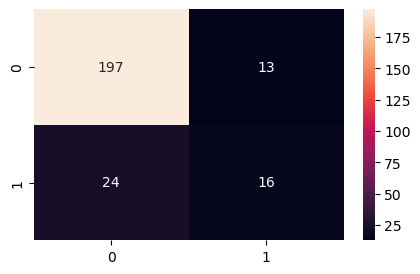

In [300]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

drop_columns = ['StandardHours', 'Over18', 'EmployeeCount', 'EmployeeNumber']

dropper = FunctionTransformer(
    func=pd.DataFrame.drop,
    kw_args={'columns': drop_columns, 'errors': 'ignore'}
)

replacer = FunctionTransformer(
    func=pd.DataFrame.replace,
    kw_args={'to_replace': {
        'OverTime': {'Yes': 1, 'No': 0},
        'MaritalStatus': {'Single': 0, 'Divorced': 1, 'Married': 2},
        'BusinessTravel': {'Non-Travel': 0, 'Travel_Rarely': 1, 'Travel_Frequently': 2}
    }}
)

operacoes_features = """
income_per_year_experience = MonthlyIncome / (TotalWorkingYears + 1)
years_without_promotion_ratio = YearsSinceLastPromotion / (YearsAtCompany + 1)
Total_Satisfaction = JobSatisfaction + EnvironmentSatisfaction + RelationshipSatisfaction + WorkLifeBalance
Years_Per_Company = TotalWorkingYears / (NumCompaniesWorked + 1)
Burnout_Risk = OverTime * (16 - Total_Satisfaction)
Tenure_to_Age_Ratio = YearsAtCompany / Age
Commute_Penalty = DistanceFromHome / (Total_Satisfaction + 1)
"""

feature_creator = FunctionTransformer(
    func=pd.DataFrame.eval,
    kw_args={'expr': operacoes_features}
)

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), make_column_selector(dtype_include=object)),
        ('num', StandardScaler(), make_column_selector(dtype_include=np.number)),
    ]
)

pipeline = Pipeline(steps=[
    ('dropper', dropper),
    ('replacer', replacer),
    ('feature_engineering', feature_creator),
    ('preprocessor', preprocessor),
    ('model', best_xgb)
])

df = pd.read_csv('./employee_data.csv')
df['Attrition'] = df['Attrition'].map({'Yes': 1, 'No': 0})

X = df.drop('Attrition', axis=1)
y = df['Attrition']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

pipeline.fit(X_train, y_train)

y_pred = pipeline.predict(X_test)
final_cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,3))
sns.heatmap(final_cm, annot=True, fmt='g')
print(classification_report(y_test, y_pred))

In [301]:
import pickle

with open('Group6_pipeline_classification.pkl', 'wb') as f:
    pickle.dump(pipeline, f)